In [1]:
import pandas as pd
import os

path = "/kaggle/input/competitions/ace-aiml-recruitmen-ts-26-1"

print(os.listdir(path))

['sample_submission.csv', 'train.csv', 'test.csv']


In [2]:
train = pd.read_csv(path + "/train.csv")
test = pd.read_csv(path + "/test.csv")
sample = pd.read_csv(path + "/sample_submission.csv")

print(train.shape)
print(test.shape)
print(sample.shape)

(2344, 82)
(586, 81)
(586, 2)


In [3]:
test = pd.read_csv(path + "/test.csv")
sample = pd.read_csv(path + "/sample_submission.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Sample:", sample.shape)

Train: (2344, 82)
Test: (586, 81)
Sample: (586, 2)


In [4]:
display(test.head())
display(sample.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,...,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal
1,2368,527450460,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal
2,2823,908128100,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal
3,2127,907135180,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
4,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,...,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal


,PID,SalePrice
0,903427090,0
1,527450460,0
2,908128100,0
3,907135180,0
4,910200080,0


In [5]:
target = list(set(train.columns) - set(test.columns))[0]

print("Target column:", target)

Target column: SalePrice


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2344 entries, 0 to 2343
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2344 non-null   int64  
 1   PID              2344 non-null   int64  
 2   MS SubClass      2344 non-null   int64  
 3   MS Zoning        2344 non-null   object 
 4   Lot Frontage     1951 non-null   float64
 5   Lot Area         2344 non-null   int64  
 6   Street           2344 non-null   object 
 7   Alley            162 non-null    object 
 8   Lot Shape        2344 non-null   object 
 9   Land Contour     2344 non-null   object 
 10  Utilities        2344 non-null   object 
 11  Lot Config       2344 non-null   object 
 12  Land Slope       2344 non-null   object 
 13  Neighborhood     2344 non-null   object 
 14  Condition 1      2344 non-null   object 
 15  Condition 2      2344 non-null   object 
 16  Bldg Type        2344 non-null   object 
 17  House Style   

In [7]:
missing = train.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Pool QC           2332
Misc Feature      2250
Alley             2182
Fence             1874
Mas Vnr Type      1426
Fireplace Qu      1144
Lot Frontage       393
Garage Cond        122
Garage Yr Blt      122
Garage Finish      122
Garage Qual        122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Total Bsmt SF        1
Bsmt Full Bath       1
BsmtFin SF 2         1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


In [8]:
categorical_cols = train.select_dtypes(include=['object']).columns
numerical_cols = train.select_dtypes(exclude=['object']).columns

print("Categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols.tolist())

Categorical columns: 43
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

Numerical columns: 39
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom

In [9]:
for col in categorical_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

In [10]:
for col in numerical_cols:
    if col != target:
        train[col] = train[col].fillna(train[col].median())
        test[col] = test[col].fillna(train[col].median())

In [11]:
print("Missing values in train:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nMissing values in test:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values in train:
Series([], dtype: int64)

Missing values in test:
Series([], dtype: int64)


In [12]:
print(target)
print(train[target].describe())

SalePrice
count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [13]:
print(train[categorical_cols].nunique().sort_values())

Street             2
Central Air        2
Land Slope         3
Alley              3
Utilities          3
Paved Drive        3
Exter Qual         4
Land Contour       4
Kitchen Qual       4
Lot Shape          4
Garage Finish      4
Bsmt Exposure      5
Mas Vnr Type       5
Exter Cond         5
Heating QC         5
Electrical         5
Fence              5
Pool QC            5
Lot Config         5
Misc Feature       5
Bldg Type          5
Heating            6
Foundation         6
Bsmt Cond          6
Garage Qual        6
Garage Cond        6
Fireplace Qu       6
Bsmt Qual          6
Roof Style         6
Sale Condition     6
MS Zoning          7
BsmtFin Type 1     7
BsmtFin Type 2     7
Garage Type        7
House Style        8
Condition 2        8
Roof Matl          8
Functional         8
Condition 1        9
Sale Type         10
Exterior 1st      16
Exterior 2nd      16
Neighborhood      28
dtype: int64


In [14]:
print(train[numerical_cols].describe().T)

                  count          mean           std          min  \
Order            2344.0  1.464299e+03  8.429823e+02          1.0   
PID              2344.0  7.143632e+08  1.886907e+08  526301100.0   
MS SubClass      2344.0  5.730802e+01  4.280256e+01         20.0   
Lot Frontage     2344.0  6.900512e+01  2.136870e+01         21.0   
Lot Area         2344.0  1.012786e+04  8.050908e+03       1300.0   
Overall Qual     2344.0  6.064420e+00  1.388520e+00          1.0   
Overall Cond     2344.0  5.581911e+00  1.105659e+00          1.0   
Year Built       2344.0  1.970507e+03  3.034143e+01       1872.0   
Year Remod/Add   2344.0  1.983924e+03  2.078629e+01       1950.0   
Mas Vnr Area     2344.0  9.774104e+01  1.717668e+02          0.0   
BsmtFin SF 1     2344.0  4.425026e+02  4.521289e+02          0.0   
BsmtFin SF 2     2344.0  5.007594e+01  1.703638e+02          0.0   
Bsmt Unf SF      2344.0  5.543541e+02  4.337000e+02          0.0   
Total Bsmt SF    2344.0  1.046997e+03  4.364756e

In [15]:
print("Target column:", target)
print(train[target].describe())

Target column: SalePrice
count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64


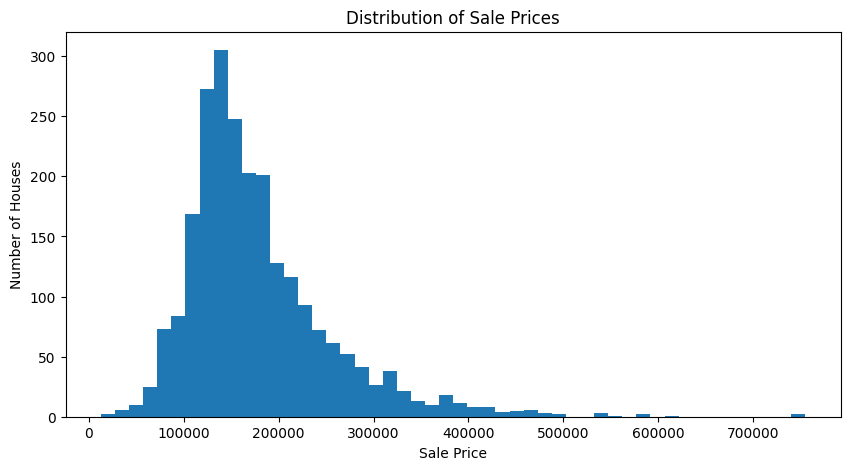

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(train[target], bins=50)

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Prices")

plt.show()

In [17]:
correlation = train[numerical_cols].corr()[target]

print(correlation.sort_values(ascending=False))

SalePrice          1.000000
Overall Qual       0.795298
Gr Liv Area        0.698315
Garage Cars        0.644218
Garage Area        0.633084
Total Bsmt SF      0.612110
1st Flr SF         0.607433
Year Built         0.545409
Full Bath          0.542053
Year Remod/Add     0.517653
Garage Yr Blt      0.499366
Mas Vnr Area       0.484157
TotRms AbvGrd      0.475455
Fireplaces         0.467501
BsmtFin SF 1       0.423835
Wood Deck SF       0.333045
Lot Frontage       0.310803
Open Porch SF      0.297722
Bsmt Full Bath     0.286825
Half Bath          0.285369
2nd Flr SF         0.278977
Lot Area           0.261336
Bsmt Unf SF        0.163629
Bedroom AbvGr      0.149269
Screen Porch       0.136936
Pool Area          0.079020
3Ssn Porch         0.034845
Mo Sold            0.030714
BsmtFin SF 2       0.027357
Low Qual Fin SF   -0.016025
Misc Val          -0.017729
Order             -0.020621
Bsmt Half Bath    -0.023531
Yr Sold           -0.037686
MS SubClass       -0.066351
Overall Cond      -0

In [18]:
correlation = train[numerical_cols].corr()[target]

top_correlations = correlation.abs().sort_values(ascending=False)

print(top_correlations.head(16))

SalePrice         1.000000
Overall Qual      0.795298
Gr Liv Area       0.698315
Garage Cars       0.644218
Garage Area       0.633084
Total Bsmt SF     0.612110
1st Flr SF        0.607433
Year Built        0.545409
Full Bath         0.542053
Year Remod/Add    0.517653
Garage Yr Blt     0.499366
Mas Vnr Area      0.484157
TotRms AbvGrd     0.475455
Fireplaces        0.467501
BsmtFin SF 1      0.423835
Wood Deck SF      0.333045
Name: SalePrice, dtype: float64


In [19]:
correlation = train[numerical_cols].corr()[target]

top_correlations = correlation.abs().sort_values(ascending=False)

print(top_correlations.head(16))

SalePrice         1.000000
Overall Qual      0.795298
Gr Liv Area       0.698315
Garage Cars       0.644218
Garage Area       0.633084
Total Bsmt SF     0.612110
1st Flr SF        0.607433
Year Built        0.545409
Full Bath         0.542053
Year Remod/Add    0.517653
Garage Yr Blt     0.499366
Mas Vnr Area      0.484157
TotRms AbvGrd     0.475455
Fireplaces        0.467501
BsmtFin SF 1      0.423835
Wood Deck SF      0.333045
Name: SalePrice, dtype: float64


In [20]:
for col in categorical_cols:
    print(col, "→", train[col].nunique(), "unique values")

MS Zoning → 7 unique values
Street → 2 unique values
Alley → 3 unique values
Lot Shape → 4 unique values
Land Contour → 4 unique values
Utilities → 3 unique values
Lot Config → 5 unique values
Land Slope → 3 unique values
Neighborhood → 28 unique values
Condition 1 → 9 unique values
Condition 2 → 8 unique values
Bldg Type → 5 unique values
House Style → 8 unique values
Roof Style → 6 unique values
Roof Matl → 8 unique values
Exterior 1st → 16 unique values
Exterior 2nd → 16 unique values
Mas Vnr Type → 5 unique values
Exter Qual → 4 unique values
Exter Cond → 5 unique values
Foundation → 6 unique values
Bsmt Qual → 6 unique values
Bsmt Cond → 6 unique values
Bsmt Exposure → 5 unique values
BsmtFin Type 1 → 7 unique values
BsmtFin Type 2 → 7 unique values
Heating → 6 unique values
Heating QC → 5 unique values
Central Air → 2 unique values
Electrical → 5 unique values
Kitchen Qual → 4 unique values
Functional → 8 unique values
Fireplace Qu → 6 unique values
Garage Type → 7 unique values


In [21]:
X = train.drop(columns=[target])
y = train[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2344, 81)
y shape: (2344,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training data: (1875, 81)
Validation data: (469, 81)


In [23]:
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(exclude=['object']).columns

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 43
Numerical features: 38


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

print("Model created successfully!")

Model created successfully!


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Faster model created!")

Faster model created!


In [27]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [28]:
y_pred = model.predict(X_valid)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[110651.72  95297.97 131784.   133686.07 155675.08 142460.16 133121.67
 130090.5  161004.09 129135.34]


In [29]:
from sklearn.metrics import mean_squared_log_error

msle = mean_squared_log_error(y_valid, y_pred)

print("Validation MSLE:", msle)

Validation MSLE: 0.0154996167703646


In [30]:
test_predictions = model.predict(test)

print(test_predictions[:10])
print("Number of predictions:", len(test_predictions))

[190949.76 104338.03 194343.83 109932.   115925.   176853.   175777.
 146907.    89196.5  346806.67]
Number of predictions: 586


In [31]:
print(sample.columns)
print(sample.head())

Index(['PID', 'SalePrice'], dtype='object')
         PID  SalePrice
0  903427090          0
1  527450460          0
2  908128100          0
3  907135180          0
4  910200080          0


In [32]:
submission = sample.copy()

submission[target] = test_predictions

print(submission.head())
print(submission.shape)

         PID  SalePrice
0  903427090  190949.76
1  527450460  104338.03
2  908128100  194343.83
3  907135180  109932.00
4  910200080  115925.00
(586, 2)


In [33]:
print("Sample shape:", sample.shape)
print("Submission shape:", submission.shape)
print("Submission columns:", submission.columns.tolist())

Sample shape: (586, 2)
Submission shape: (586, 2)
Submission columns: ['PID', 'SalePrice']


In [34]:
submission.to_csv('/kaggle/working/submission.csv', index=False)

print("submission.csv created!")

submission.csv created!


In [35]:
import os

print(os.path.exists('/kaggle/working/submission.csv'))

True
